In [1]:
import torch
import torchvision
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
import torchvision.models.resnet as resnet
import torch.optim as Optimizers
import torch.optim.lr_scheduler as Scheduler
import os
import torch.nn as nn

In [2]:
model = models.resnet34(weights=resnet.ResNet34_Weights.IMAGENET1K_V1)

model.fc 

Linear(in_features=512, out_features=1000, bias=True)

In [3]:
transform = transforms.Compose([
                transforms.Resize((255, 255)),
                transforms.CenterCrop((224, 224)),
                transforms.RandomHorizontalFlip(),
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.5169, 0.4732, 0.3455], std=[0.2184, 0.2107, 0.2059])
                ])

In [4]:
# data_train = datasets.ImageFolder('./data/hymenoptera_data/train', transform=transform)
# loader = DataLoader(data_train, shuffle=True, batch_size=32)

# mean = 0.
# std = 0.
# n_samples = 0

# for imgs, _ in loader:
#     batch_samples = imgs.size(0)    
#     imgs = imgs.view(batch_samples, imgs.size(1), -1)
    
#     mean += imgs.mean(2).sum(0)
#     std += imgs.std(2).sum(0)
    
#     n_samples += batch_samples

# mean /= n_samples
# std /= n_samples

# print(mean, std)

In [23]:
data_train = datasets.ImageFolder('./data/hymenoptera_data/train', transform=transform) 
data_test = datasets.ImageFolder('./data/hymenoptera_data/val', transform=transform) 

data_train_loader = DataLoader(dataset=data_train, batch_size=4, shuffle=True)
data_test_loader = DataLoader(dataset=data_test, batch_size=4, shuffle=True)

In [6]:
customfc = nn.Linear(in_features=512, out_features=2)

model.fc = customfc


In [7]:
for param in model.parameters(): 
    param.requires_grad = False

for param in model.fc.parameters():
    param.requires_grad = True

In [8]:
for param in model.parameters(): 
    print(param.requires_grad)


False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
True
True


In [9]:
learning_rate = 0.001
loss_function = nn.CrossEntropyLoss()
optimizer = Optimizers.AdamW(params = model.fc.parameters(), lr=learning_rate)

lr_scheduler = Scheduler.StepLR(optimizer=optimizer, step_size=7, gamma=0.1)

In [10]:
CUDA = torch.cuda.is_available()
if CUDA:
    model = model.cuda()

epochs = 25
model.train()
for epoch in range(epochs):
    loss_per_epoch = 0
    accuracy_per_epoch = 0

    for imgs, labels in data_train_loader:
        imgs, labels = imgs.cuda(), labels.cuda()

        optimizer.zero_grad()

        predict = model(imgs)
        loss = loss_function(predict, labels)

        loss.backward()
        optimizer.step()

        loss_per_epoch += loss.item()
        _, predict_labels = torch.max(predict, 1)
        accuracy_per_epoch += (predict_labels == labels).sum().item()

    lr_scheduler.step()

    loss_per_epoch /= len(data_train_loader)
    accuracy_per_epoch /= len(data_train_loader.dataset)
    print(f"Epoch {epoch+1}, Loss: {loss_per_epoch:.4f}, Accuracy: {accuracy_per_epoch:.4f}")

    

Epoch 1, Loss: 0.6276, Accuracy: 0.6270
Epoch 2, Loss: 0.4227, Accuracy: 0.8197
Epoch 3, Loss: 0.4345, Accuracy: 0.7951
Epoch 4, Loss: 0.3466, Accuracy: 0.8525
Epoch 5, Loss: 0.3277, Accuracy: 0.8566
Epoch 6, Loss: 0.3526, Accuracy: 0.8402
Epoch 7, Loss: 0.3395, Accuracy: 0.8484
Epoch 8, Loss: 0.3121, Accuracy: 0.8566
Epoch 9, Loss: 0.2964, Accuracy: 0.8811
Epoch 10, Loss: 0.3056, Accuracy: 0.8689
Epoch 11, Loss: 0.1932, Accuracy: 0.9344
Epoch 12, Loss: 0.3495, Accuracy: 0.8525
Epoch 13, Loss: 0.2111, Accuracy: 0.9221
Epoch 14, Loss: 0.2571, Accuracy: 0.9139
Epoch 15, Loss: 0.2961, Accuracy: 0.8975
Epoch 16, Loss: 0.2340, Accuracy: 0.9016
Epoch 17, Loss: 0.3316, Accuracy: 0.8443
Epoch 18, Loss: 0.2493, Accuracy: 0.9016
Epoch 19, Loss: 0.2434, Accuracy: 0.9098
Epoch 20, Loss: 0.3329, Accuracy: 0.8484
Epoch 21, Loss: 0.2360, Accuracy: 0.9098
Epoch 22, Loss: 0.2635, Accuracy: 0.9016
Epoch 23, Loss: 0.2626, Accuracy: 0.8975
Epoch 24, Loss: 0.2751, Accuracy: 0.8852
Epoch 25, Loss: 0.2528, A

In [30]:
model.eval()
loss_per_epoch = 0
accuracy_per_epoch = 0
batch_loop = 0

with torch.no_grad():
    for imgs, labels in data_test_loader:
        imgs, labels = imgs.cuda(), labels.cuda()

        predict = model(imgs)
        loss = loss_function(predict, labels)

        loss_per_epoch += loss.item()
        batch_loop += 1

        _, predict_labels = torch.max(predict, 1)
        accuracy_per_epoch += (predict_labels == labels).sum().item()

accuracy_per_epoch /= len(data_test_loader.dataset)
loss_per_epoch /= batch_loop

print(f"Test Loss: {loss_per_epoch:.4f}, Test Accuracy: {accuracy_per_epoch:.4f}")

Test Loss: 0.1906, Test Accuracy: 0.9216


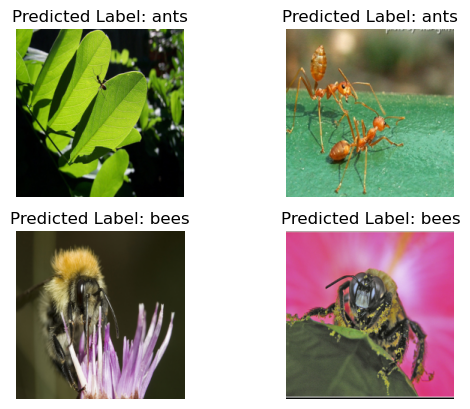

In [32]:
#Visualize some predictions 
import matplotlib.pyplot as plt
import numpy as np

fig = plt.figure()
shown_batch = 0
index = 0
with torch.no_grad():
    for (images, labels) in data_test_loader:
        if shown_batch == 1:
            break
        shown_batch += 1
        if torch.cuda.is_available():
            images = images.cuda()
            labels = labels.cuda()

        outputs = model(images)                            #The output is of shape (4,2)
        _, preds = torch.max(outputs, 1)                        #The pred is of shape (4) --> [ 0,  0,  0,  1]
        
        for i in range(4):
            index += 1
            ax = plt.subplot(2,2,index)
            ax.axis('off')
            ax.set_title('Predicted Label: {}'.format(data_train.classes[preds[i]]))
            input_img = images.cpu().data[i]                    #Get the tensor of the image, and put it to cpu  
            inp = input_img.numpy().transpose((1, 2, 0))        #If we have a tensor of shape (2,3,4) --> it becomes (3,4,2)
            mean = np.array([0.5169, 0.4732, 0.3455])
            std = np.array([0.2184, 0.2107, 0.2059])
            inp = std * inp + mean
            inp = np.clip(inp, 0, 1)
            plt.imshow(inp)